# MIDI Music Generation — Training & Generation
## CodeAlpha Task 3 — Notebook 2

---

### What this notebook does

We take the preprocessed sequences from Notebook 1 (`X.npy`, `y.npy`, `vocab.json`) and:
1. Build a **Stacked LSTM + Attention** model in PyTorch
2. Train it to predict the next musical token given a sequence of 64 tokens
3. Generate a new music sequence from a random seed
4. Convert the generated sequence to a `.mid` file using `music21`

### Why LSTM for music?

Music is a **sequence** — what comes next depends on what came before.
LSTM (Long Short-Term Memory) is a type of RNN designed to handle sequences
with long-range dependencies. It has an internal **cell state** that acts as
memory — it can "remember" patterns from many steps ago.

Think of it like a musician who remembers the key, tempo, and motifs
established at the beginning of a piece while improvising a new phrase.

### Architecture overview

```
Token sequence (64 tokens)
        │
        ▼
   Embedding layer        ← converts token IDs to dense vectors
        │
        ▼
   LSTM layer 1 (1024)    ← learns local patterns (intervals, rhythms)
        │
        ▼
   LSTM layer 2 (1024)    ← learns higher-level patterns (phrases, motifs)
        │
        ▼
   Attention layer        ← lets the model focus on the most relevant past tokens
        │
        ▼
   Linear + Softmax       ← outputs a probability for each token in the vocabulary
        │
        ▼
   Next token prediction
```

## 1. Install dependencies

In [1]:
# music21 is needed only at generation time (MIDI export)
# torch is pre-installed on Kaggle GPU instances
!pip install music21 -q

## 2. Imports & configuration

In [2]:
import os
import json
import math
import time
import random
import logging
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ── Logging ──────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)-8s | %(message)s',
    datefmt='%H:%M:%S',
    stream=sys.stdout,
)
logger = logging.getLogger(__name__)

# ── Reproducibility ───────────────────────────────────────────────────────────
# Setting seeds ensures the same results across runs.
# Important for debugging and fair comparison of experiments.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Environment detection ─────────────────────────────────────────────────────
ON_KAGGLE = os.path.exists('/kaggle/input/')
logger.info("Environment: %s", "KAGGLE" if ON_KAGGLE else "LOCAL")

if ON_KAGGLE:
    # On Kaggle: preprocessed data is added as a dataset input
    DATA_DIR   = "/kaggle/input/datasets/tahsinekajolasalami/vocab-data"  # update with your dataset name
    OUTPUT_DIR = "/kaggle/working"
else:
    DATA_DIR   = "./output"   # output from notebook 1
    OUTPUT_DIR = "./output"

# ── GPU setup ─────────────────────────────────────────────────────────────────
# DataParallel automatically splits batches across all available GPUs.
# On Kaggle with 2×T4: each GPU processes half the batch simultaneously.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_gpus = torch.cuda.device_count()
logger.info("Device : %s", device)
logger.info("GPUs   : %d", n_gpus)
if n_gpus > 0:
    for i in range(n_gpus):
        vram = torch.cuda.get_device_properties(i).total_memory / 1e9
        logger.info("  GPU %d : %s — %.1f GB VRAM", i,
                    torch.cuda.get_device_properties(i).name, vram)

# ── Hyperparameters ───────────────────────────────────────────────────────────
# These are the key decisions we made before coding:
#
# HIDDEN_SIZE 1024 : large enough to capture complex musical patterns.
#                    We have 46M events so overfitting risk is low.
#
# NUM_LAYERS 2    : two stacked LSTMs. Layer 1 learns local patterns
#                   (note intervals, rhythm), layer 2 learns higher-level
#                   patterns (phrases, motifs).
#
# EMBED_DIM 256   : each token is represented as a 256-dimensional vector.
#                   Standard for vocabularies in the 5k-15k range.
#
# BATCH_SIZE 256  : fills ~26GB of the 30GB VRAM available on 2×T4.
#                   Larger batches = more stable gradients.
#
# DROPOUT 0.3     : randomly zeroes 30% of activations during training.
#                   Acts as regularization — prevents the model from
#                   memorizing the training data instead of learning patterns.
#
# EPOCHS 50       : number of full passes over the dataset.
#                   With early stopping, training may finish before epoch 50.
#
# LR 0.001        : Adam optimizer learning rate. Standard starting point.
#                   ReduceLROnPlateau will lower it automatically if loss plateaus.

HIDDEN_SIZE  = 1024
NUM_LAYERS   = 2
EMBED_DIM    = 256
BATCH_SIZE   = 256
DROPOUT      = 0.3
EPOCHS       = 50
LR           = 0.001
PATIENCE     = 5      # early stopping: stop if val loss doesn't improve for 5 epochs
GRAD_CLIP    = 5.0    # gradient clipping: prevents exploding gradients in LSTM

logger.info("Hyperparameters:")
logger.info("  Hidden size  : %d", HIDDEN_SIZE)
logger.info("  Num layers   : %d", NUM_LAYERS)
logger.info("  Embed dim    : %d", EMBED_DIM)
logger.info("  Batch size   : %d", BATCH_SIZE)
logger.info("  Dropout      : %.1f", DROPOUT)
logger.info("  Epochs       : %d", EPOCHS)
logger.info("  Learning rate: %.4f", LR)
logger.info("  Patience     : %d", PATIENCE)
logger.info("  Grad clip    : %.1f", GRAD_CLIP)

06:30:21 | INFO     | Environment: KAGGLE
06:30:21 | INFO     | Device : cuda
06:30:21 | INFO     | GPUs   : 2
06:30:21 | INFO     |   GPU 0 : Tesla T4 — 15.6 GB VRAM
06:30:21 | INFO     |   GPU 1 : Tesla T4 — 15.6 GB VRAM
06:30:21 | INFO     | Hyperparameters:
06:30:21 | INFO     |   Hidden size  : 1024
06:30:21 | INFO     |   Num layers   : 2
06:30:21 | INFO     |   Embed dim    : 256
06:30:21 | INFO     |   Batch size   : 256
06:30:21 | INFO     |   Dropout      : 0.3
06:30:21 | INFO     |   Epochs       : 50
06:30:21 | INFO     |   Learning rate: 0.0010
06:30:21 | INFO     |   Patience     : 5
06:30:21 | INFO     |   Grad clip    : 5.0


## 3. Load preprocessed data

We load the three files produced by Notebook 1:
- `X.npy` — input sequences (1,460,190 × 64)
- `y.npy` — target tokens (1,460,190,)
- `vocab.json` — token ↔ index mappings and config

In [3]:
logger.info("Loading preprocessed data from %s...", DATA_DIR)

X = np.load(os.path.join(DATA_DIR, "X.npy"))
y = np.load(os.path.join(DATA_DIR, "y.npy"))

with open(os.path.join(DATA_DIR, "vocab.json")) as f:
    vocab = json.load(f)

VOCAB_SIZE   = vocab["vocab_size"]
SEQUENCE_LEN = vocab["sequence_len"]

import ast

# idx2token : "0" → (pitch, duration, velocity)
idx2token = {int(k): tuple(v) for k, v in vocab["idx2token"].items()}

# token2idx : "(21, 'dotted_eighth', 'f')" → 0
# Keys are string representations of tuples — use ast.literal_eval to parse them
token2idx = {ast.literal_eval(k): v for k, v in vocab["token2idx"].items()}

logger.info("X shape      : %s", X.shape)
logger.info("y shape      : %s", y.shape)
logger.info("Vocab size   : %d", VOCAB_SIZE)
logger.info("Sequence len : %d", SEQUENCE_LEN)

06:30:21 | INFO     | Loading preprocessed data from /kaggle/input/datasets/tahsinekajolasalami/vocab-data...
06:30:24 | INFO     | X shape      : (1460190, 64)
06:30:24 | INFO     | y shape      : (1460190,)
06:30:24 | INFO     | Vocab size   : 6543
06:30:24 | INFO     | Sequence len : 64


## 4. Dataset & DataLoader

PyTorch's `Dataset` class wraps our numpy arrays so the `DataLoader`
can serve them as mini-batches during training.

We split 90% for training and 10% for validation.
The validation set lets us detect overfitting: if training loss keeps
going down but validation loss goes up, the model is memorizing — not learning.

In [4]:
class MIDIDataset(Dataset):
    """Simple wrapper around numpy arrays for PyTorch DataLoader."""

    def __init__(self, X: np.ndarray, y: np.ndarray):
        # Convert to torch tensors once — no copy per batch
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ── Train / validation split ──────────────────────────────────────────────────
n_total   = len(X)
n_train   = int(n_total * 0.9)
n_val     = n_total - n_train

# Shuffle indices before splitting so both sets are representative
indices   = np.random.permutation(n_total)
train_idx = indices[:n_train]
val_idx   = indices[n_train:]

train_dataset = MIDIDataset(X[train_idx], y[train_idx])
val_dataset   = MIDIDataset(X[val_idx],   y[val_idx])

# num_workers=4: use 4 CPU threads to load data in parallel while GPU trains
# pin_memory=True: keeps data in pinned memory for faster GPU transfer
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=4, pin_memory=True)

logger.info("Train sequences : %d  (%d batches)", n_train, len(train_loader))
logger.info("Val sequences   : %d  (%d batches)", n_val,   len(val_loader))

06:30:24 | INFO     | Train sequences : 1314171  (5134 batches)
06:30:24 | INFO     | Val sequences   : 146019  (571 batches)


## 5. Model architecture

### Embedding layer
Each token (an integer index) is mapped to a dense vector of size `EMBED_DIM`.
This is the same idea as word embeddings in NLP — tokens that appear in
similar musical contexts will have similar vectors after training.

### Stacked LSTM
Two LSTM layers, each with 1024 hidden units.
- **Layer 1** sees the raw sequence and learns immediate patterns:
  which notes follow which, basic rhythmic cells.
- **Layer 2** sees the output of layer 1 and learns abstract patterns:
  phrases, motifs, harmonic progressions.

### Attention
Standard dot-product attention over the LSTM output sequence.
Instead of only using the last hidden state, attention computes a
**weighted sum** of all positions — the model learns which past tokens
matter most for predicting the next one.

Analogy: when improvising the end of a phrase, a musician glances back
at the opening motif for inspiration. Attention is that "glance back".

In [5]:
class Attention(nn.Module):
    """
    Additive (Bahdanau-style) attention over LSTM output.

    Given the LSTM output sequence of shape (batch, seq_len, hidden),
    computes a context vector by taking a weighted sum of all positions.
    The weights are learned — the model decides which positions matter.
    """

    def __init__(self, hidden_size: int):
        super().__init__()
        # A small linear layer that scores each position
        self.attn = nn.Linear(hidden_size, 1)

    def forward(self, lstm_out: torch.Tensor) -> torch.Tensor:
        # lstm_out : (batch, seq_len, hidden_size)
        scores  = self.attn(lstm_out).squeeze(-1)         # (batch, seq_len)
        weights = torch.softmax(scores, dim=-1).unsqueeze(-1)  # (batch, seq_len, 1)
        context = (lstm_out * weights).sum(dim=1)         # (batch, hidden_size)
        return context


class MusicLSTM(nn.Module):
    """
    Stacked LSTM + Attention for symbolic music generation.

    Input  : sequence of token indices  (batch, seq_len)
    Output : logits over vocabulary     (batch, vocab_size)
    """

    def __init__(self, vocab_size: int, embed_dim: int,
                 hidden_size: int, num_layers: int, dropout: float):
        super().__init__()

        # 1. Embedding: token index → dense vector
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # 2. Stacked LSTM
        #    batch_first=True: input shape (batch, seq_len, features)
        #    dropout between layers (not applied on the last layer)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # 3. Attention over the full LSTM output sequence
        self.attention = Attention(hidden_size)

        # 4. Dropout before the classifier (additional regularization)
        self.dropout = nn.Dropout(dropout)

        # 5. Classifier: hidden → vocabulary logits
        self.fc = nn.Linear(hidden_size, vocab_size)

        # Weight initialization: small uniform values for embedding,
        # orthogonal for LSTM weights (helps with gradient flow in deep LSTMs)
        self._init_weights()

    def _init_weights(self):
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (batch, seq_len)
        embedded  = self.dropout(self.embedding(x))  # (batch, seq_len, embed_dim)
        lstm_out, _ = self.lstm(embedded)             # (batch, seq_len, hidden_size)
        context   = self.attention(lstm_out)          # (batch, hidden_size)
        out       = self.dropout(context)
        logits    = self.fc(out)                      # (batch, vocab_size)
        return logits


# ── Instantiate & wrap with DataParallel ─────────────────────────────────────
model = MusicLSTM(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
)

# DataParallel splits each batch across all available GPUs.
# On 2×T4: batch of 256 → GPU 0 gets 128, GPU 1 gets 128.
# Gradients are averaged automatically before the optimizer step.
if n_gpus > 1:
    model = nn.DataParallel(model)
    logger.info("DataParallel enabled across %d GPUs", n_gpus)

model = model.to(device)

# Count parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
logger.info("Model parameters: %s", f"{n_params:,}")
logger.info("Model:\n%s", model)

06:30:25 | INFO     | DataParallel enabled across 2 GPUs
06:30:26 | INFO     | Model parameters: 22,030,480
06:30:26 | INFO     | Model:
DataParallel(
  (module): MusicLSTM(
    (embedding): Embedding(6543, 256)
    (lstm): LSTM(256, 1024, num_layers=2, batch_first=True, dropout=0.3)
    (attention): Attention(
      (attn): Linear(in_features=1024, out_features=1, bias=True)
    )
    (dropout): Dropout(p=0.3, inplace=False)
    (fc): Linear(in_features=1024, out_features=6543, bias=True)
  )
)


## 6. Training setup

### Loss function: CrossEntropyLoss
At each step, the model predicts a probability distribution over all
6543 tokens. CrossEntropy measures how wrong that distribution is
compared to the correct answer. We minimize this error over the dataset.

### Optimizer: Adam
Adam adapts the learning rate per parameter automatically.
Better than plain SGD for sequence models.

### Learning rate scheduler: ReduceLROnPlateau
If validation loss doesn't improve for 2 epochs, halve the learning rate.
This helps the model converge to a better minimum without manual tuning.

### Gradient clipping
LSTMs can suffer from **exploding gradients** — very large gradient values
that destabilize training. Clipping caps the gradient norm at 5.0.

In [6]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=LR)

# Halve LR if val loss doesn't improve for 2 consecutive epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

logger.info("Loss      : CrossEntropyLoss")
logger.info("Optimizer : Adam (lr=%.4f)", LR)
logger.info("Scheduler : ReduceLROnPlateau (factor=0.5, patience=2)")
logger.info("Grad clip : %.1f", GRAD_CLIP)

06:30:32 | INFO     | Loss      : CrossEntropyLoss
06:30:32 | INFO     | Optimizer : Adam (lr=0.0010)
06:30:32 | INFO     | Scheduler : ReduceLROnPlateau (factor=0.5, patience=2)
06:30:32 | INFO     | Grad clip : 5.0


## 7. Training loop

Each epoch:
1. **Train** — forward pass, compute loss, backward pass, update weights
2. **Validate** — forward pass only, no weight updates
3. **Save checkpoint** if validation loss improved (best model)
4. **Early stopping** if no improvement for `PATIENCE` epochs

In [7]:
CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, "best_model.pt")
HISTORY_PATH    = os.path.join(OUTPUT_DIR, "training_history.json")

best_val_loss  = float('inf')
patience_count = 0
history        = {"train_loss": [], "val_loss": [], "lr": []}


def run_epoch(loader, train: bool) -> float:
    """Run one epoch. Returns average loss."""
    model.train(train)
    total_loss = 0.0

    with torch.set_grad_enabled(train):
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            logits = model(X_batch)              # (batch, vocab_size)
            loss   = criterion(logits, y_batch)

            if train:
                optimizer.zero_grad()
                loss.backward()
                # Gradient clipping: prevent exploding gradients
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()

            total_loss += loss.item()

    return total_loss / len(loader)


logger.info("Starting training — %d epochs, early stopping patience=%d",
            EPOCHS, PATIENCE)
logger.info("-" * 65)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss = run_epoch(train_loader, train=True)
    val_loss   = run_epoch(val_loader,   train=False)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["lr"].append(current_lr)

    elapsed = time.time() - t0
    improved = val_loss < best_val_loss

    if improved:
        best_val_loss  = val_loss
        patience_count = 0
        # Save the full model state
        torch.save({
            "epoch":      epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_loss":   val_loss,
            "vocab_size": VOCAB_SIZE,
            "config": {
                "hidden_size":  HIDDEN_SIZE,
                "num_layers":   NUM_LAYERS,
                "embed_dim":    EMBED_DIM,
                "sequence_len": SEQUENCE_LEN,
            },
        }, CHECKPOINT_PATH)
    else:
        patience_count += 1

    logger.info(
        "Epoch %3d/%d | train=%.4f | val=%.4f | lr=%.6f | %.1fs %s",
        epoch, EPOCHS, train_loss, val_loss, current_lr, elapsed,
        "✓ best" if improved else f"(patience {patience_count}/{PATIENCE})"
    )

    # Save history after every epoch
    with open(HISTORY_PATH, "w") as f:
        json.dump(history, f, indent=2)

    if patience_count >= PATIENCE:
        logger.info("Early stopping triggered at epoch %d.", epoch)
        break

logger.info("-" * 65)
logger.info("Training complete. Best val loss: %.4f", best_val_loss)
logger.info("Best model saved to: %s", CHECKPOINT_PATH)

06:30:32 | INFO     | Starting training — 50 epochs, early stopping patience=5
06:30:32 | INFO     | -----------------------------------------------------------------
06:55:55 | INFO     | Epoch   1/50 | train=6.8345 | val=6.4067 | lr=0.001000 | 1522.3s ✓ best
07:21:22 | INFO     | Epoch   2/50 | train=6.2675 | val=6.1177 | lr=0.001000 | 1526.1s ✓ best
07:46:55 | INFO     | Epoch   3/50 | train=6.0586 | val=5.9961 | lr=0.001000 | 1532.3s ✓ best
08:12:23 | INFO     | Epoch   4/50 | train=5.9059 | val=5.9000 | lr=0.001000 | 1527.8s ✓ best
08:38:01 | INFO     | Epoch   5/50 | train=5.7813 | val=5.8559 | lr=0.001000 | 1536.8s ✓ best
09:03:31 | INFO     | Epoch   6/50 | train=5.6807 | val=5.8318 | lr=0.001000 | 1529.6s ✓ best
09:29:08 | INFO     | Epoch   7/50 | train=5.5885 | val=5.8146 | lr=0.001000 | 1536.0s ✓ best
09:55:01 | INFO     | Epoch   8/50 | train=5.5050 | val=5.8055 | lr=0.001000 | 1552.9s ✓ best
10:20:39 | INFO     | Epoch   9/50 | train=5.4291 | val=5.8113 | lr=0.001000 | 15

## 8. Loss curve

A good training run shows:
- Both curves going down together
- Val loss slightly above train loss (normal)
- No divergence (val going up while train goes down = overfitting)

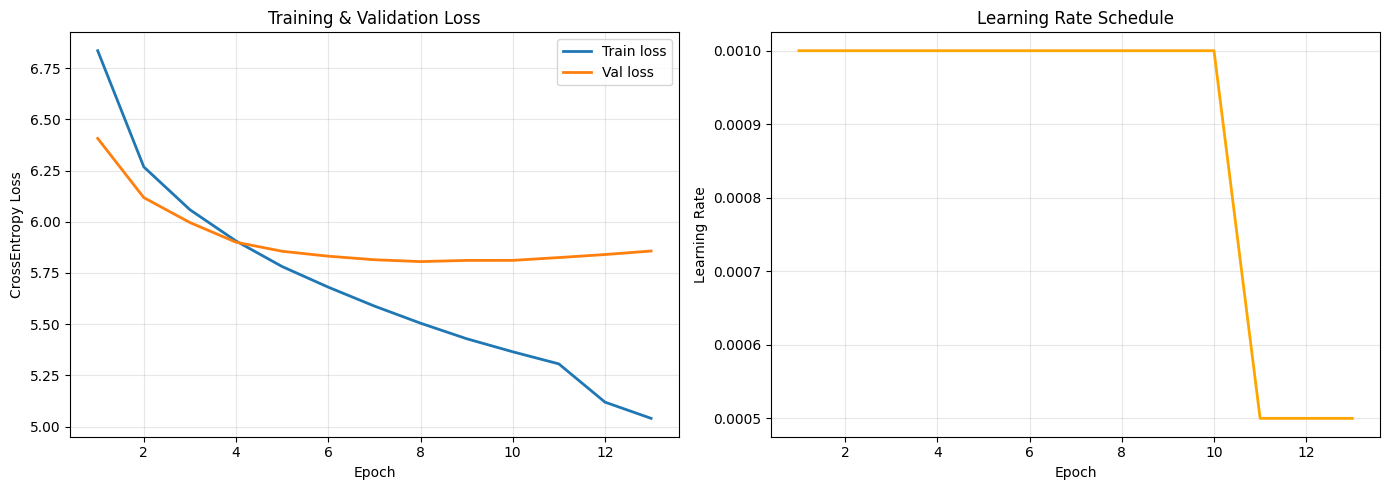

12:03:31 | INFO     | Loss curves saved.


In [8]:
import matplotlib.pyplot as plt

with open(HISTORY_PATH) as f:
    history = json.load(f)

epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(epochs_ran, history["train_loss"], label="Train loss", linewidth=2)
ax1.plot(epochs_ran, history["val_loss"],   label="Val loss",   linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("CrossEntropy Loss")
ax1.set_title("Training & Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Learning rate schedule
ax2.plot(epochs_ran, history["lr"], color="orange", linewidth=2)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Learning Rate")
ax2.set_title("Learning Rate Schedule")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()
logger.info("Loss curves saved.")

## 9. Music generation

### How generation works

1. Pick a random seed sequence from the dataset
2. Feed it to the model → get logits over 6543 tokens
3. Apply **temperature** to control creativity:
   - Low (0.7): conservative, more repetitive
   - High (1.1): creative, more surprising
4. Sample the next token from the distribution
5. Append to sequence, slide window, repeat

This is **autoregressive generation** — the same technique used by
language models like GPT to generate text token by token.

In [9]:
def generate_sequence(
    model: nn.Module,
    seed_sequence: list[int],
    n_tokens: int,
    temperature: float,
    device: torch.device,
) -> list[int]:
    """
    Generate n_tokens new tokens autoregressively.

    Args:
        seed_sequence : list of token indices to start from
        n_tokens      : how many new tokens to generate
        temperature   : controls randomness (0.7=conservative, 1.1=creative)

    Returns:
        list of generated token indices
    """
    # Use the underlying module if wrapped in DataParallel
    base_model = model.module if hasattr(model, 'module') else model
    base_model.eval()

    generated  = []
    current_seq = list(seed_sequence[-SEQUENCE_LEN:])

    with torch.no_grad():
        for _ in range(n_tokens):
            x = torch.tensor([current_seq], dtype=torch.long).to(device)
            logits = base_model(x)              # (1, vocab_size)

            # Temperature scaling:
            # divide logits by temperature before softmax.
            # Lower temp → sharper distribution (more confident)
            # Higher temp → flatter distribution (more random)
            scaled   = logits[0] / temperature
            probs    = torch.softmax(scaled, dim=-1)
            next_tok = torch.multinomial(probs, 1).item()

            generated.append(next_tok)
            current_seq = current_seq[1:] + [next_tok]  # slide window

    return generated


# ── Load best model checkpoint ────────────────────────────────────────────────
ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state"])
logger.info("Loaded best model from epoch %d (val_loss=%.4f)",
            ckpt["epoch"], ckpt["val_loss"])

# ── Pick a random seed from validation set ────────────────────────────────────
seed_idx = random.randint(0, len(val_dataset) - 1)
seed_seq = val_dataset[seed_idx][0].tolist()
logger.info("Seed sequence index: %d", seed_idx)

# ── Generate with three different temperatures ────────────────────────────────
N_TOKENS     = 256   # ~256 notes = ~1-2 minutes of music at moderate tempo
temperatures = [0.7, 0.9, 1.1]

generated_sequences = {}
for temp in temperatures:
    logger.info("Generating %d tokens at temperature %.1f...", N_TOKENS, temp)
    generated_sequences[temp] = generate_sequence(
        model, seed_seq, N_TOKENS, temp, device
    )
    logger.info("  Done.")

logger.info("Generation complete.")

12:03:31 | INFO     | Loaded best model from epoch 8 (val_loss=5.8055)
12:03:31 | INFO     | Seed sequence index: 29184
12:03:31 | INFO     | Generating 256 tokens at temperature 0.7...
12:03:34 | INFO     |   Done.
12:03:34 | INFO     | Generating 256 tokens at temperature 0.9...
12:03:37 | INFO     |   Done.
12:03:37 | INFO     | Generating 256 tokens at temperature 1.1...
12:03:39 | INFO     |   Done.
12:03:39 | INFO     | Generation complete.


## 10. Convert to MIDI & save

We decode each generated token back to (pitch, duration, velocity)
and build a MIDI file using `music21`.

The duration bucket labels ("eighth", "quarter"...) map back to
quarter length values that music21 understands natively.

In [10]:
from music21 import stream, note, tempo as m21_tempo

# Map duration bucket labels back to quarter length floats
DURATION_MAP = {
    "thirty_second":  0.125,
    "sixteenth":      0.25,
    "eighth":         0.5,
    "dotted_eighth":  0.75,
    "quarter":        1.0,
    "dotted_quarter": 1.5,
    "half":           2.0,
    "dotted_half":    3.0,
    "whole":          4.0,
    "long":           4.0,   # clip long notes to whole note
}

# Map velocity bucket labels back to MIDI velocity integers (midpoint of range)
VELOCITY_MAP = {
    "ppp":  8,
    "pp":   24,
    "p":    40,
    "mp":   56,
    "mf":   72,
    "f":    88,
    "ff":   104,
    "fff":  120,
}


def tokens_to_midi(token_indices: list[int], idx2token: dict,
                   output_path: str, bpm: int = 120):
    """
    Convert a list of token indices to a MIDI file.

    Args:
        token_indices : generated token indices
        idx2token     : index → (pitch, duration_label, velocity_label)
        output_path   : where to save the .mid file
        bpm           : beats per minute (tempo)
    """
    part = stream.Part()
    part.append(m21_tempo.MetronomeMark(number=bpm))

    for idx in token_indices:
        pitch_midi, dur_label, vel_label = idx2token[idx]

        quarter_len = DURATION_MAP.get(dur_label, 1.0)
        velocity    = VELOCITY_MAP.get(vel_label, 64)

        n = note.Note()
        n.pitch.midi          = pitch_midi
        n.duration.quarterLength = quarter_len
        n.volume.velocity     = velocity
        part.append(n)

    s = stream.Score([part])
    s.write('midi', fp=output_path)


# ── Save one MIDI per temperature ─────────────────────────────────────────────
for temp, tokens in generated_sequences.items():
    out_path = os.path.join(OUTPUT_DIR, f"generated_temp{str(temp).replace('.','')}.mid")
    tokens_to_midi(tokens, idx2token, out_path, bpm=120)
    size_kb = os.path.getsize(out_path) / 1000
    logger.info("Saved: %s (%.1f KB, %d notes)", out_path, size_kb, len(tokens))

logger.info("\nAll MIDI files saved. Listen and compare the three temperatures.")
logger.info("temp=0.7 → conservative  |  temp=0.9 → balanced  |  temp=1.1 → creative")

12:03:41 | INFO     | Saved: /kaggle/working/generated_temp07.mid (2.6 KB, 256 notes)
12:03:42 | INFO     | Saved: /kaggle/working/generated_temp09.mid (2.5 KB, 256 notes)
12:03:42 | INFO     | Saved: /kaggle/working/generated_temp11.mid (2.5 KB, 256 notes)
12:03:42 | INFO     | 
All MIDI files saved. Listen and compare the three temperatures.
12:03:42 | INFO     | temp=0.7 → conservative  |  temp=0.9 → balanced  |  temp=1.1 → creative
